In [1]:
from google.colab import files
uploaded = files.upload()

import pandas as pd

df = pd.read_csv("digital_behavior_dataset.csv")
df.head()

Saving digital_behavior_dataset.csv to digital_behavior_dataset.csv


,user_id,daily_screen_time_hours,sleep_duration_hours,stress_level,physical_activity_minutes,caffeine_intake_cups,phone_usage_before_sleep_minutes,sleep_quality_score,occupation
0,1,5.12,4.93,7,20,3,75,1,Teacher
1,2,11.46,6.71,3,98,3,89,4,Doctor
2,3,9.05,8.36,7,75,2,9,5,Business
3,4,7.59,7.66,8,25,4,95,6,Doctor
4,5,2.72,8.03,6,114,2,175,5,Business


In [3]:
print("Shape:", df.shape)
df.info()
df.describe()


Shape: (1000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           1000 non-null   int64  
 1   daily_screen_time_hours           1000 non-null   float64
 2   sleep_duration_hours              1000 non-null   float64
 3   stress_level                      1000 non-null   int64  
 4   physical_activity_minutes         1000 non-null   int64  
 5   caffeine_intake_cups              1000 non-null   int64  
 6   phone_usage_before_sleep_minutes  1000 non-null   int64  
 7   sleep_quality_score               1000 non-null   int64  
 8   occupation                        1000 non-null   object 
dtypes: float64(2), int64(6), object(1)
memory usage: 70.4+ KB


,user_id,daily_screen_time_hours,sleep_duration_hours,stress_level,physical_activity_minutes,caffeine_intake_cups,phone_usage_before_sleep_minutes,sleep_quality_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,6.392930,6.535120,5.005000,59.848000,2.55600,91.244000,4.956000
std,288.819436,3.213309,1.460804,2.603796,34.326888,1.68811,52.215466,2.550798
min,1.000000,1.050000,4.020000,1.000000,0.000000,0.00000,0.000000,1.000000
25%,250.750000,3.595000,5.207500,3.000000,31.000000,1.00000,45.000000,3.000000
50%,500.500000,6.465000,6.595000,5.000000,60.000000,3.00000,92.000000,5.000000
75%,750.250000,9.185000,7.800000,7.000000,88.250000,4.00000,135.000000,7.000000
max,1000.000000,12.000000,9.000000,9.000000,119.000000,5.00000,179.000000,9.000000


In [4]:
# Missing values
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

user_id                             0
daily_screen_time_hours             0
sleep_duration_hours                0
stress_level                        0
physical_activity_minutes           0
caffeine_intake_cups                0
phone_usage_before_sleep_minutes    0
sleep_quality_score                 0
occupation                          0
dtype: int64


In [5]:
# Screen Addiction Level
df['screen_addiction_level'] = pd.cut(
    df['daily_screen_time_hours'],
    bins=[0,3,6,9,24],
    labels=['Low','Moderate','High','Extreme']
)

# Sleep Category
df['sleep_category'] = pd.cut(
    df['sleep_duration_hours'],
    bins=[0,5,7,9,24],
    labels=['Poor','Average','Healthy','Oversleep']
)

# Stress Category
df['stress_category'] = pd.cut(
    df['stress_level'],
    bins=[0,3,6,10],
    labels=['Low','Moderate','High']
)

In [6]:
df['digital_risk_score'] = (
    df['daily_screen_time_hours'] * 2 +
    df['stress_level'] * 1.5 +
    df['phone_usage_before_sleep_minutes'] * 0.05
) - (
    df['sleep_duration_hours'] * 2 +
    df['physical_activity_minutes'] * 0.03
)

df['risk_level'] = pd.cut(
    df['digital_risk_score'],
    bins=[-100, 0, 20, 40, 100],
    labels=['Low Risk', 'Moderate Risk', 'High Risk', 'Critical']
)

In [7]:
df["lifestyle_score"] = (
    df['sleep_duration_hours']*2 +
    df['physical_activity_minutes']*0.5
) - (
    df['daily_screen_time_hours']*1.5 +
    df['caffeine_intake_cups']*2
)

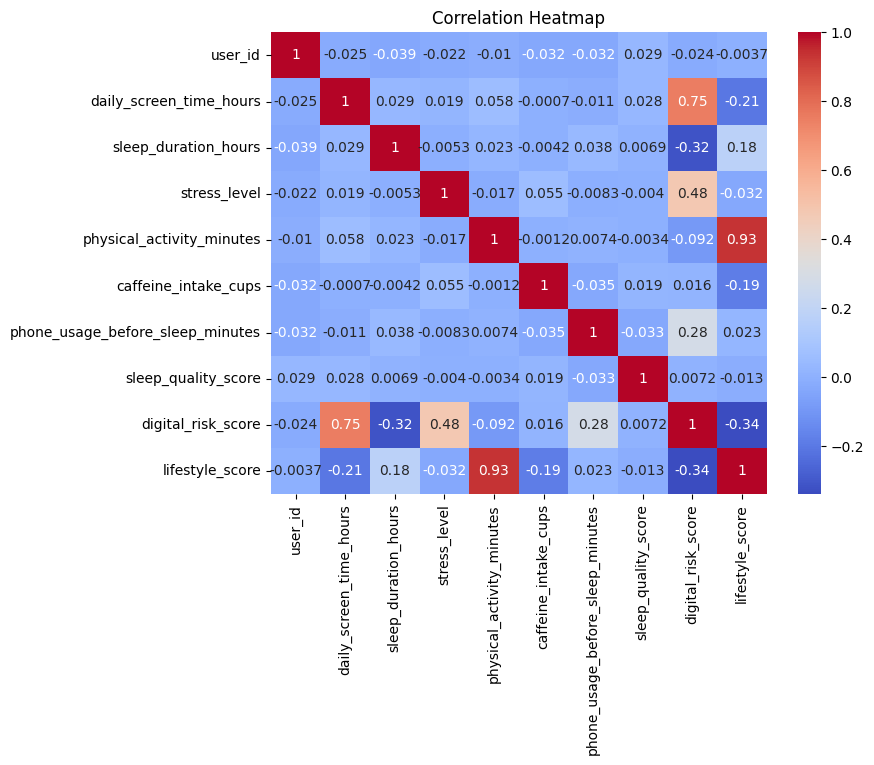

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

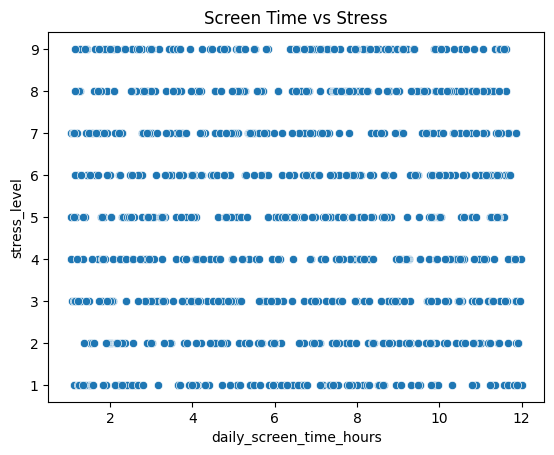

In [9]:
sns.scatterplot(
    x="daily_screen_time_hours",
    y="stress_level",
    data=df
)
plt.title("Screen Time vs Stress")
plt.show()

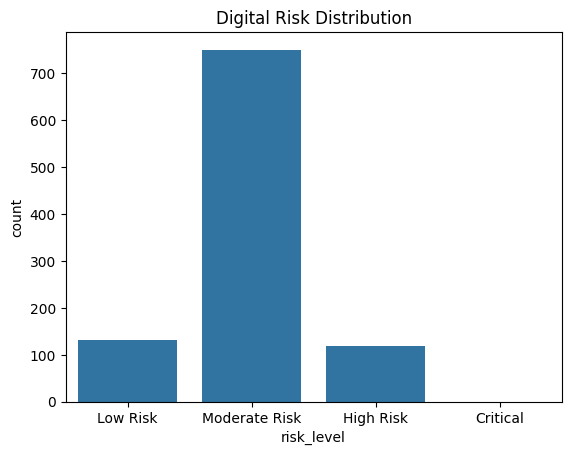

In [10]:
sns.countplot(x='risk_level', data=df)
plt.title("Digital Risk Distribution")
plt.show()

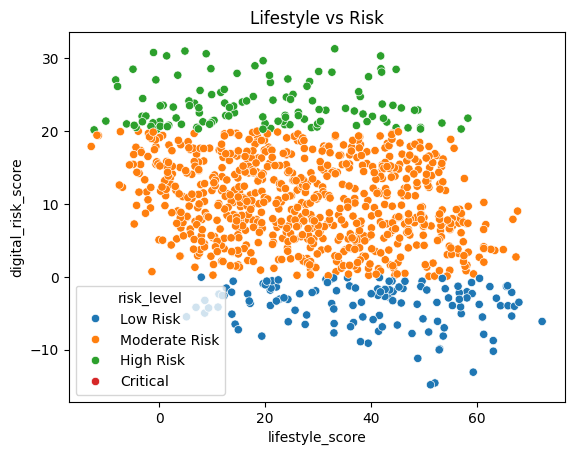

In [11]:
sns.scatterplot(
    x='lifestyle_score',
    y='digital_risk_score',
    hue='risk_level',
    data=df
)
plt.title("Lifestyle vs Risk")
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

features = [
    'daily_screen_time_hours',
    'sleep_duration_hours',
    'physical_activity_minutes',
    'caffeine_intake_cups'
]

X = df[features]
y = df['stress_level']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, predictions))

MAE: 2.3771


In [13]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05)

df['anomaly'] = iso.fit_predict(df[features])

print(df['anomaly'].value_counts())

anomaly
 1    950
-1     50
Name: count, dtype: int64


In [14]:
def give_advice(row):
    if row['daily_screen_time_hours'] > 8:
        return "Reduce screen time"
    elif row['sleep_duration_hours'] < 6:
        return "Improve sleep"
    elif row['physical_activity_minutes'] < 30:
        return "Increase physical activity"
    else:
        return "Good lifestyle"

df['recommendation'] = df.apply(give_advice, axis=1)

df[['daily_screen_time_hours','sleep_duration_hours','recommendation']].head()

,daily_screen_time_hours,sleep_duration_hours,recommendation
0,5.12,4.93,Improve sleep
1,11.46,6.71,Reduce screen time
2,9.05,8.36,Reduce screen time
3,7.59,7.66,Increase physical activity
4,2.72,8.03,Good lifestyle


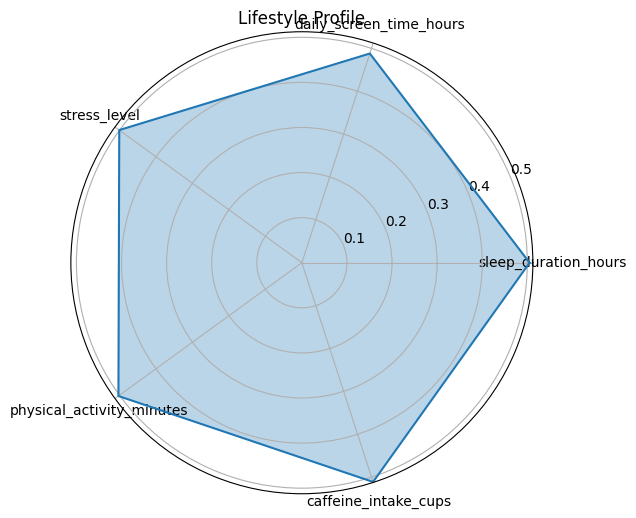

In [17]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

features = [
    'sleep_duration_hours',
    'daily_screen_time_hours',
    'stress_level',
    'physical_activity_minutes',
    'caffeine_intake_cups'
]

scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[features])

avg = scaled.mean(axis=0)

angles = np.linspace(0, 2*np.pi, len(features), endpoint=False)

avg = np.concatenate((avg, [avg[0]]))
angles = np.concatenate((angles, [angles[0]]))

plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)

ax.plot(angles, avg)
ax.fill(angles, avg, alpha=0.3)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(features)

plt.title("Lifestyle Profile")
plt.show()

In [16]:
print("Most Common Risk Level:", df['risk_level'].value_counts().idxmax())
print("Average Stress Level:", df['stress_level'].mean())
print("Average Screen Time:", df['daily_screen_time_hours'].mean())

Most Common Risk Level: Moderate Risk
Average Stress Level: 5.005
Average Screen Time: 6.392930000000001
